# Gradient Boosting

In [1]:
import os
import librosa
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\HP\AppData\Local\Temp\ipykernel_17416\2893808396.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(emotion_counts.keys()), y=list(emotion_counts.values()), palette="viridis")


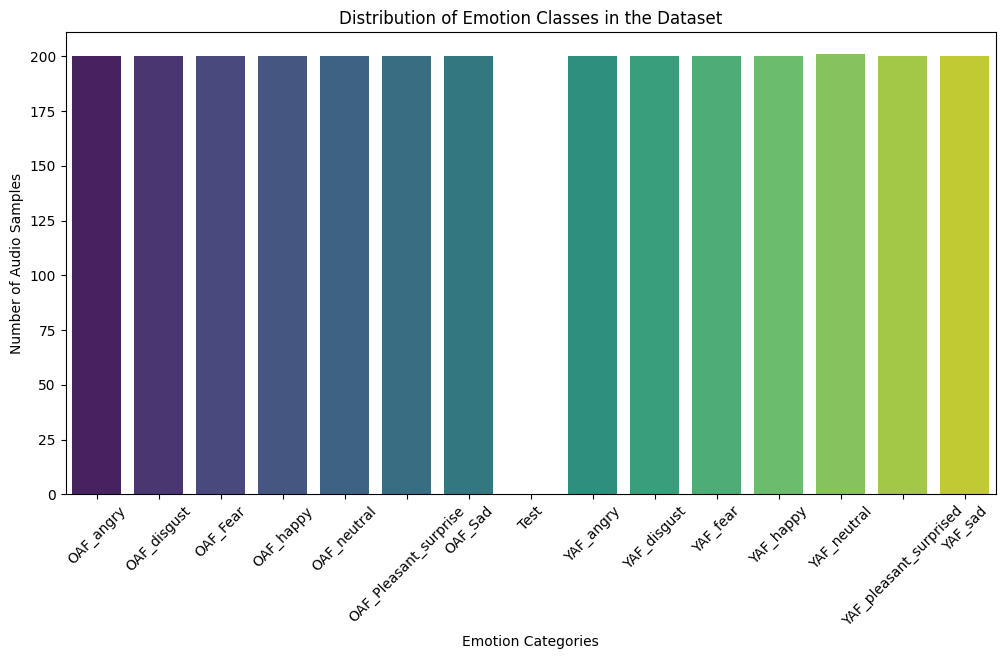

In [17]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Define the dataset path
dataset_path = "D:/PYTHON/SPEECH/Tess"

# Custom emotion classes
emotions = {
    0: 'OAF_Fear', 1: 'OAF_Pleasant_surprise', 2: 'OAF_Sad', 3: 'OAF_angry',
    4: 'OAF_disgust', 5: 'OAF_happy', 6: 'OAF_neutral', 7: 'YAF_angry',
    8: 'YAF_disgust', 9: 'YAF_fear', 10: 'YAF_happy', 11: 'YAF_neutral',
    12: 'YAF_pleasant_surprised', 13: 'YAF_sad'
}

# Count the number of files per emotion
emotion_counts = Counter()
for emotion in os.listdir(dataset_path):
    emotion_folder = os.path.join(dataset_path, emotion)
    if os.path.isdir(emotion_folder):
        num_files = len([f for f in os.listdir(emotion_folder) if f.endswith(".wav")])
        emotion_counts[emotion] = num_files

# Plot distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(emotion_counts.keys()), y=list(emotion_counts.values()), palette="viridis")
plt.xticks(rotation=45)
plt.xlabel("Emotion Categories")
plt.ylabel("Number of Audio Samples")
plt.title("Distribution of Emotion Classes in the Dataset")
plt.show()


In [18]:
# Function to extract MFCC features
def extract_features(file_path):
    audio, sr = librosa.load(file_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    return mfcc_mean

# Prepare training data
features, labels = [], []
for label_id, emotion in emotions.items():
    emotion_folder = os.path.join(dataset_path, emotion)
    if os.path.exists(emotion_folder):  # Check if folder exists
        for file in os.listdir(emotion_folder):
            if file.endswith(".wav"):
                file_path = os.path.join(emotion_folder, file)
                mfccs = extract_features(file_path)
                features.append(mfccs)
                labels.append(label_id)

In [19]:
# Convert to numpy arrays
X_train, y_train = np.array(features), np.array(labels)

# Train Gradient Boosting Classifier
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Prepare test data
test_features, test_labels = [], []
for label_id, emotion in emotions.items():
    emotion_folder = os.path.join(test_dataset_path, emotion)
    if os.path.exists(emotion_folder):  # Check if folder exists
        for file in os.listdir(emotion_folder):
            if file.endswith(".wav"):
                file_path = os.path.join(emotion_folder, file)
                mfccs = extract_features(file_path)
                test_features.append(mfccs)
                test_labels.append(label_id)

# Convert to numpy arrays
X_test, y_test = np.array(test_features), np.array(test_labels)
# Predictions
y_pred = model.predict(X_test)

In [20]:
# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Overall Accuracy:", accuracy)

# Compute precision, recall, F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

df_metrics = pd.DataFrame({
    'Emotion': emotions.values(),
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1_score
})
df_metrics.to_csv("emotion_classification_metrics_rf_new.csv", index=False)
print("\nPer-Class Metrics:\n", df_metrics)



Overall Accuracy: 0.9996429846483399

Per-Class Metrics:
                    Emotion  Precision    Recall  F1-score
0                 OAF_Fear   1.000000  1.000000  1.000000
1    OAF_Pleasant_surprise   1.000000  1.000000  1.000000
2                  OAF_Sad   1.000000  1.000000  1.000000
3                OAF_angry   1.000000  1.000000  1.000000
4              OAF_disgust   1.000000  1.000000  1.000000
5                OAF_happy   1.000000  1.000000  1.000000
6              OAF_neutral   1.000000  1.000000  1.000000
7                YAF_angry   1.000000  1.000000  1.000000
8              YAF_disgust   0.995025  1.000000  0.997506
9                 YAF_fear   1.000000  1.000000  1.000000
10               YAF_happy   1.000000  1.000000  1.000000
11             YAF_neutral   1.000000  0.995025  0.997506
12  YAF_pleasant_surprised   1.000000  1.000000  1.000000
13                 YAF_sad   1.000000  1.000000  1.000000


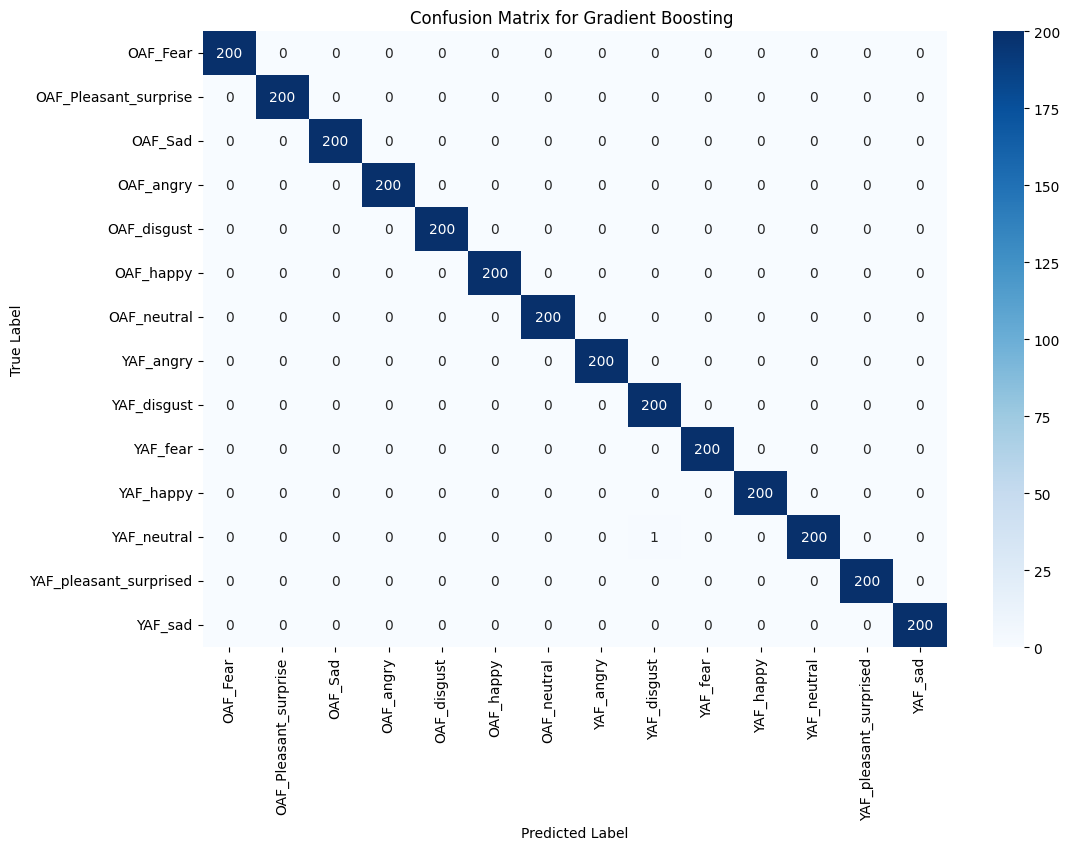

In [21]:
# Plot Confusion Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=emotions.values(), yticklabels=emotions.values())
plt.title("Confusion Matrix for Gradient Boosting ")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Save Confusion Matrix Figure in High Resolution
plt.savefig("confusion_matrix_high_res.png", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

In [22]:
import joblib

# Save the model
joblib.dump(model, 'gradient_boosting.pkl')

# Load the model
loaded_model = joblib.load('gradient_boosting.pkl')


In [23]:
import numpy as np
import librosa
import joblib

# Function to extract MFCC features (Ensure it matches training settings)
def extract_features(file_path, n_mfcc=40):
    audio, sr = librosa.load(file_path, sr=22050)  # Load audio
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)  # Extract 40 MFCCs
    mfcc_mean = np.mean(mfcc.T, axis=0)  # Compute mean of MFCC features
    return mfcc_mean

# Load trained model
model_path = "gradient_boosting.pkl"  # Update with your model filename
gb_model = joblib.load(model_path)

# Emotion label mapping
emotions = { 0: 'OAF_Fear', 
    1: 'OAF_Pleasant_surprise', 
    2: 'OAF_Sad', 
    3: 'OAF_angry',
    4: 'OAF_disgust', 
    5: 'OAF_happy', 
    6: 'OAF_neutral', 
    7: 'YAF_angry',
    8: 'YAF_disgust', 
    9: 'YAF_fear', 
    10: 'YAF_happy', 
    11: 'YAF_neutral',
    12: 'YAF_pleasant_surprised', 
    13: 'YAF_sad'}

# Function to predict emotion
def predict_emotion(file_path):
    features = extract_features(file_path)  # Extract 40 MFCC features
    prediction = gb_model.predict([features])[0]  # Make prediction
    return emotions[prediction]  # Return predicted emotion

# Example usage
file_path = r"D:\PYTHON\SPEECH\Tess\OAF_Sad\OAF_bite_sad.wav"  # Replace with actual file path
predicted_emotion = predict_emotion(file_path)

print(f"Predicted Emotion: {predicted_emotion}")


Predicted Emotion: OAF_Sad


# Random Forest

In [24]:
import os
import librosa
import numpy as np
import pandas as pd
import joblib  # For saving & loading model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support


C:\Users\HP\AppData\Local\Temp\ipykernel_17416\2216069962.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(emotion_counts.keys()), y=list(emotion_counts.values()), palette="viridis")


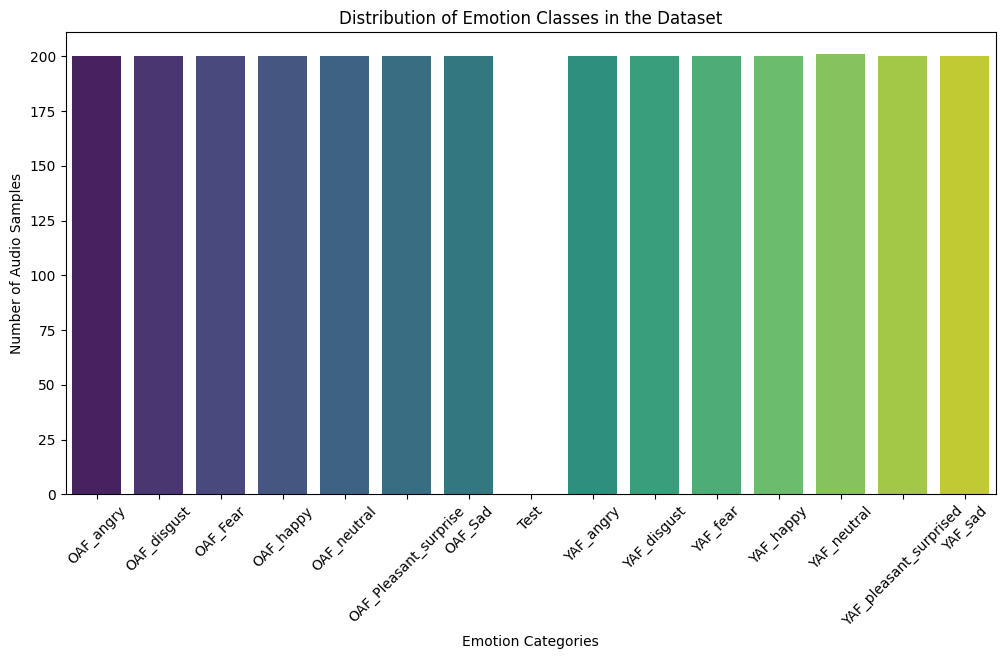

In [25]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Define the dataset path
dataset_path = "D:/PYTHON/SPEECH/Tess"
test_dataset_path = "D:/PYTHON/SPEECH/Tess/test"

# Custom emotion classes
emotions = {
    0: 'OAF_Fear', 1: 'OAF_Pleasant_surprise', 2: 'OAF_Sad', 3: 'OAF_angry',
    4: 'OAF_disgust', 5: 'OAF_happy', 6: 'OAF_neutral', 7: 'YAF_angry',
    8: 'YAF_disgust', 9: 'YAF_fear', 10: 'YAF_happy', 11: 'YAF_neutral',
    12: 'YAF_pleasant_surprised', 13: 'YAF_sad'
}

# Count the number of files per emotion
emotion_counts = Counter()
for emotion in os.listdir(dataset_path):
    emotion_folder = os.path.join(dataset_path, emotion)
    if os.path.isdir(emotion_folder):
        num_files = len([f for f in os.listdir(emotion_folder) if f.endswith(".wav")])
        emotion_counts[emotion] = num_files

# Plot distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(emotion_counts.keys()), y=list(emotion_counts.values()), palette="viridis")
plt.xticks(rotation=45)
plt.xlabel("Emotion Categories")
plt.ylabel("Number of Audio Samples")
plt.title("Distribution of Emotion Classes in the Dataset")
plt.show()


In [26]:
def extract_features(file_path, n_mfcc=40):
    """Extracts MFCC features from an audio file."""
    audio, sr = librosa.load(file_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfcc.T, axis=0)


In [27]:
# Extract features and labels for training
features, labels = [], []

for label_id, emotion in emotions.items():
    emotion_folder = os.path.join(dataset_path, emotion)
    if os.path.exists(emotion_folder):
        for file in os.listdir(emotion_folder):
            if file.endswith(".wav"):
                file_path = os.path.join(emotion_folder, file)
                features.append(extract_features(file_path))
                labels.append(label_id)

X_train, y_train = np.array(features), np.array(labels)


In [28]:
# Extract features and labels for training
features, labels = [], []

for label_id, emotion in emotions.items():
    emotion_folder = os.path.join(dataset_path, emotion)
    if os.path.exists(emotion_folder):
        for file in os.listdir(emotion_folder):
            if file.endswith(".wav"):
                file_path = os.path.join(emotion_folder, file)
                features.append(extract_features(file_path))
                labels.append(label_id)

X_train, y_train = np.array(features), np.array(labels)


In [29]:
# Train Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Save the trained model
model_filename = "random_forest_emotion_model.pkl"
joblib.dump(model, model_filename)
print(f"Model saved as {model_filename}")


Model saved as random_forest_emotion_model.pkl


In [30]:
# Extract features and labels for testing
test_features, test_labels = [], []

for label_id, emotion in emotions.items():
    emotion_folder = os.path.join(test_dataset_path, emotion)
    if os.path.exists(emotion_folder):
        for file in os.listdir(emotion_folder):
            if file.endswith(".wav"):
                file_path = os.path.join(emotion_folder, file)
                test_features.append(extract_features(file_path))
                test_labels.append(label_id)

X_test, y_test = np.array(test_features), np.array(test_labels)


In [31]:
# Load the trained model
model = joblib.load(model_filename)

# Predict on test set
y_pred = model.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Overall Accuracy:", accuracy)

# Compute per-class precision, recall, F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

df_metrics = pd.DataFrame({
    'Emotion': emotions.values(),
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1_score
})

df_metrics.to_csv("emotion_classification_metrics_rf.csv", index=False)
print("\nPer-Class Metrics:\n", df_metrics)


Overall Accuracy: 0.9996429846483399

Per-Class Metrics:
                    Emotion  Precision    Recall  F1-score
0                 OAF_Fear   1.000000  1.000000  1.000000
1    OAF_Pleasant_surprise   1.000000  1.000000  1.000000
2                  OAF_Sad   1.000000  1.000000  1.000000
3                OAF_angry   1.000000  1.000000  1.000000
4              OAF_disgust   1.000000  1.000000  1.000000
5                OAF_happy   1.000000  1.000000  1.000000
6              OAF_neutral   1.000000  1.000000  1.000000
7                YAF_angry   1.000000  1.000000  1.000000
8              YAF_disgust   0.995025  1.000000  0.997506
9                 YAF_fear   1.000000  1.000000  1.000000
10               YAF_happy   1.000000  1.000000  1.000000
11             YAF_neutral   1.000000  0.995025  0.997506
12  YAF_pleasant_surprised   1.000000  1.000000  1.000000
13                 YAF_sad   1.000000  1.000000  1.000000


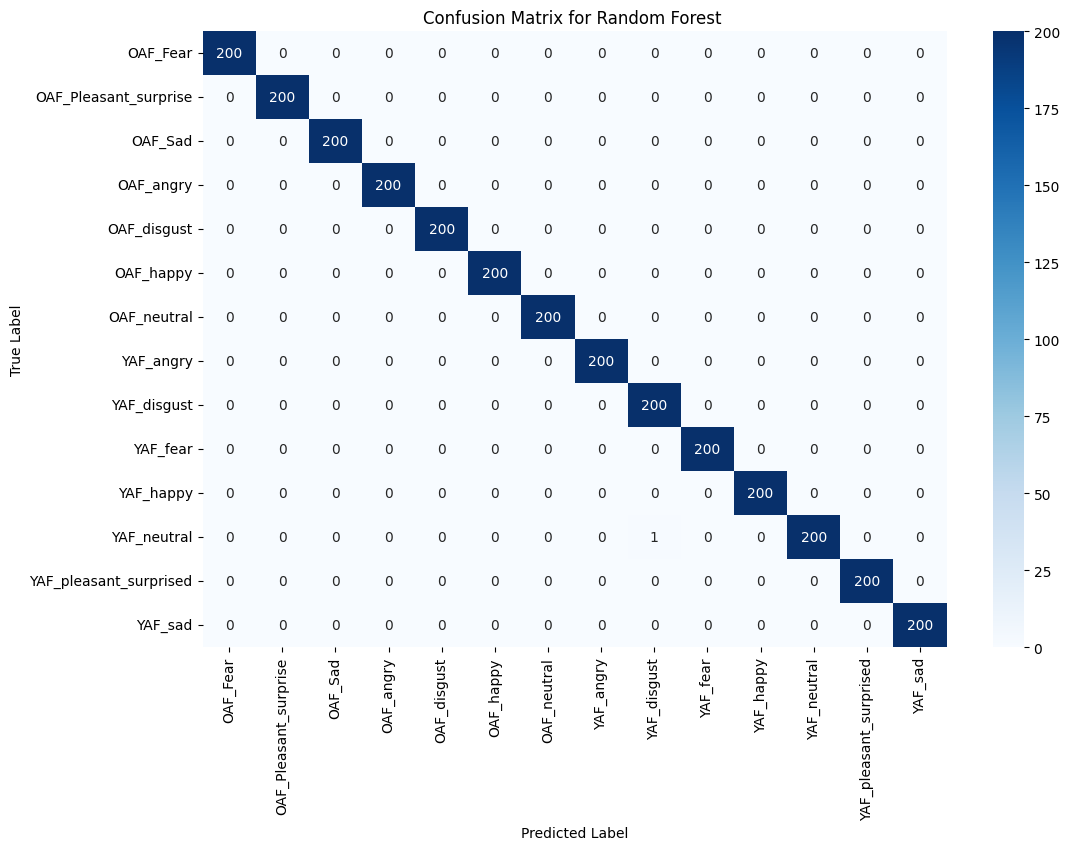

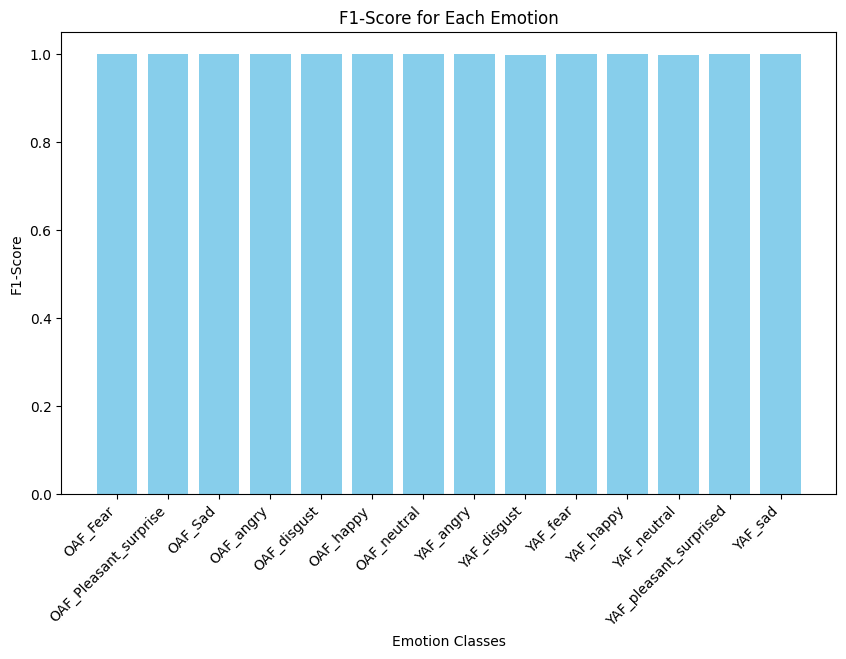

In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=emotions.values(), yticklabels=emotions.values())
plt.title("Confusion Matrix for Random Forest ")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("confusion_matrix_rf.png", dpi=300, bbox_inches="tight")
plt.show()

# Accuracy Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(emotions.values(), f1_score, color='skyblue')
plt.xlabel("Emotion Classes")
plt.ylabel("F1-Score")
plt.title("F1-Score for Each Emotion")
plt.xticks(rotation=45, ha="right")
plt.savefig("f1_score_rf.png", dpi=300, bbox_inches="tight")
plt.show()


In [33]:
def predict_emotion(file_path):
    """Predicts the emotion of a given audio file."""
    features = extract_features(file_path).reshape(1, -1)  # Reshape for model input
    prediction = model.predict(features)[0]
    return emotions[prediction]

# Example Usage
file_path = r"D:\PYTHON\SPEECH\Tess\OAF_Sad\OAF_bite_sad.wav"  # Replace with actual file path
predicted_emotion = predict_emotion(file_path)

print(f"Predicted Emotion: {predicted_emotion}")


Predicted Emotion: OAF_Sad


# MLP

In [34]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler

In [35]:
# Path to your dataset
dataset_path = "D:/PYTHON/SPEECH/Tess"
test_dataset_path = "D:/PYTHON/SPEECH/Tess/test"

# Custom emotion classes
emotions = {
    0: 'OAF_Fear', 
    1: 'OAF_Pleasant_surprise', 
    2: 'OAF_Sad', 
    3: 'OAF_Angry',
    4: 'OAF_Disgust', 
    5: 'OAF_Happy', 
    6: 'OAF_Neutral', 
    7: 'YAF_Angry',
    8: 'YAF_Disgust', 
    9: 'YAF_Fear', 
    10: 'YAF_Happy', 
    11: 'YAF_Neutral',
    12: 'YAF_Pleasant_surprised', 
    13: 'YAF_Sad'
}


In [36]:


# Extract MFCC features from an audio file
def extract_features(file_path):
    audio, sr = librosa.load(file_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    return mfcc_mean


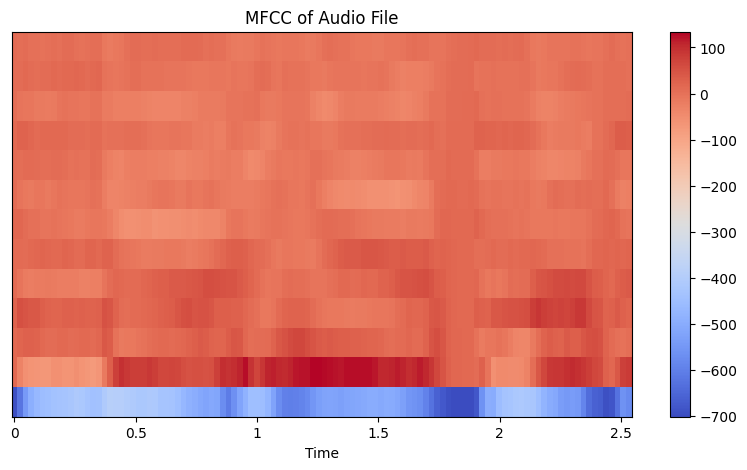

In [37]:
import librosa.display

# Load a sample audio file
file_path = "D:\PYTHON\SPEECH\Tess\OAF_Sad\OAF_cheek_sad.wav"  # Change this to your test file
audio, sr = librosa.load(file_path, sr=22050)

# Compute MFCCs
mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

# Plot MFCCs
plt.figure(figsize=(10, 5))
librosa.display.specshow(mfcc, x_axis='time', sr=sr)
plt.colorbar()
plt.title('MFCC of Audio File')
plt.show()


In [38]:
# Prepare training data
features, labels = [], []

for label_id, emotion in emotions.items():
    emotion_folder = os.path.join(dataset_path, emotion)
    for file in os.listdir(emotion_folder):
        if file.endswith(".wav"):
            file_path = os.path.join(emotion_folder, file)
            features.append(extract_features(file_path))
            labels.append(label_id)

# Convert to numpy arrays and normalize features
X_train = np.array(features)
y_train = np.array(labels)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# One-hot encode labels
y_train_encoded = to_categorical(y_train, num_classes=len(emotions))


In [42]:
# Build MLP Model
model = Sequential([
    Dense(256, input_dim=X_train.shape[1], activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(len(emotions), activation='softmax')
])

# Compile & Train
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])



Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5897 - loss: 1.5534 - val_accuracy: 0.2834 - val_loss: 5.3549
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9804 - loss: 0.1055 - val_accuracy: 0.2870 - val_loss: 6.4946
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9898 - loss: 0.0500 - val_accuracy: 0.2870 - val_loss: 6.9305
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9974 - loss: 0.0249 - val_accuracy: 0.2870 - val_loss: 7.1970
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9918 - loss: 0.0301 - val_accuracy: 0.2870 - val_loss: 7.1157
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9991 - loss: 0.0093 - val_accuracy: 0.2870 - val_loss: 7.8003
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9991 - loss: 0.0069 - val_accuracy: 0.2870 - val_loss: 8.5600
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9991 - loss: 0.0077 - val_accuracy: 0.2870 - val_loss:

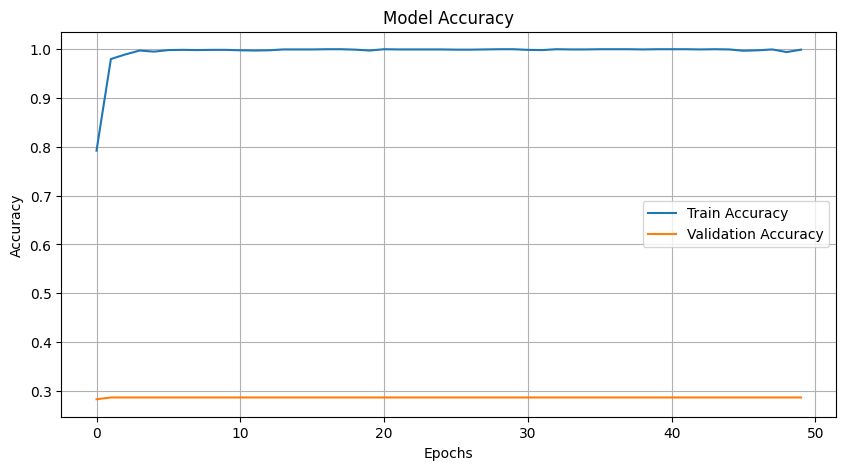

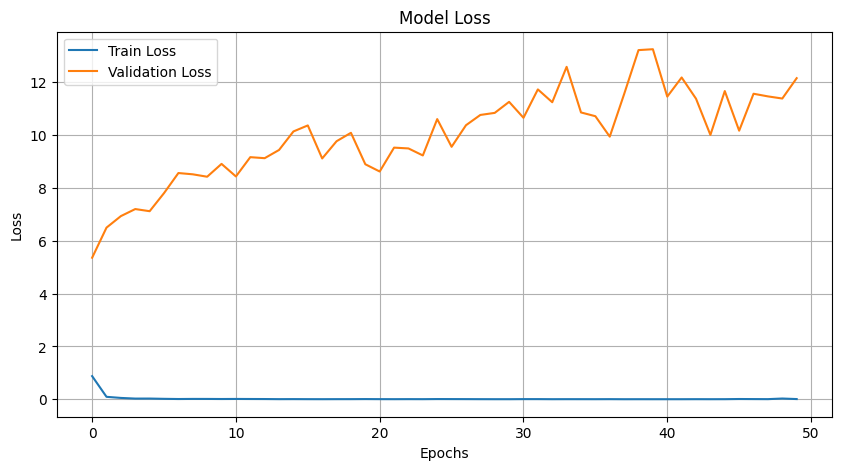

In [43]:
import matplotlib.pyplot as plt

# Assuming you have the history object from model training
history = model.fit(X_train, y_train_encoded, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Plot accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [44]:

# Prepare test data
test_features, test_labels = [], []

for label_id, emotion in emotions.items():
    emotion_folder = os.path.join(test_dataset_path, emotion)
    for file in os.listdir(emotion_folder):
        if file.endswith(".wav"):
            file_path = os.path.join(emotion_folder, file)
            test_features.append(extract_features(file_path))
            test_labels.append(label_id)

# Convert & Normalize test data
X_test = np.array(test_features)
y_test = np.array(test_labels)
X_test = scaler.transform(X_test)

# One-hot encode test labels
y_test_encoded = to_categorical(y_test, num_classes=len(emotions))

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_encoded, axis=1)


88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [45]:

# Overall Accuracy
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print("\nOverall Accuracy:", accuracy)

# Classification Report (Precision, Recall, F1-score for each class)
report = classification_report(y_test_classes, y_pred_classes, target_names=emotions.values(), output_dict=True)

# Print precision, recall, F1-score for each class
print("\nDetailed Class-wise Metrics:\n")
for emotion, metrics in report.items():
    if emotion in emotions.values():  # Ensuring only class-wise metrics are printed
        print(f"Emotion: {emotion}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall: {metrics['recall']:.4f}")
        print(f"  F1-score: {metrics['f1-score']:.4f}")
        print(f"  Support: {metrics['support']}\n")



Overall Accuracy: 0.8561228132809711

Detailed Class-wise Metrics:

Emotion: OAF_Fear
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Support: 200.0

Emotion: OAF_Pleasant_surprise
  Precision: 0.9259
  Recall: 1.0000
  F1-score: 0.9615
  Support: 200.0

Emotion: OAF_Sad
  Precision: 0.9709
  Recall: 1.0000
  F1-score: 0.9852
  Support: 200.0

Emotion: OAF_Angry
  Precision: 0.9756
  Recall: 1.0000
  F1-score: 0.9877
  Support: 200.0

Emotion: OAF_Disgust
  Precision: 0.8547
  Recall: 1.0000
  F1-score: 0.9217
  Support: 200.0

Emotion: OAF_Happy
  Precision: 1.0000
  Recall: 0.9900
  F1-score: 0.9950
  Support: 200.0

Emotion: OAF_Neutral
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Support: 200.0

Emotion: YAF_Angry
  Precision: 0.6270
  Recall: 1.0000
  F1-score: 0.7707
  Support: 200.0

Emotion: YAF_Disgust
  Precision: 0.4963
  Recall: 1.0000
  F1-score: 0.6633
  Support: 200.0

Emotion: YAF_Fear
  Precision: 0.9434
  Recall: 1.0000
  F1-score: 0.9709
  Sup

c:\python39\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\python39\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\python39\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


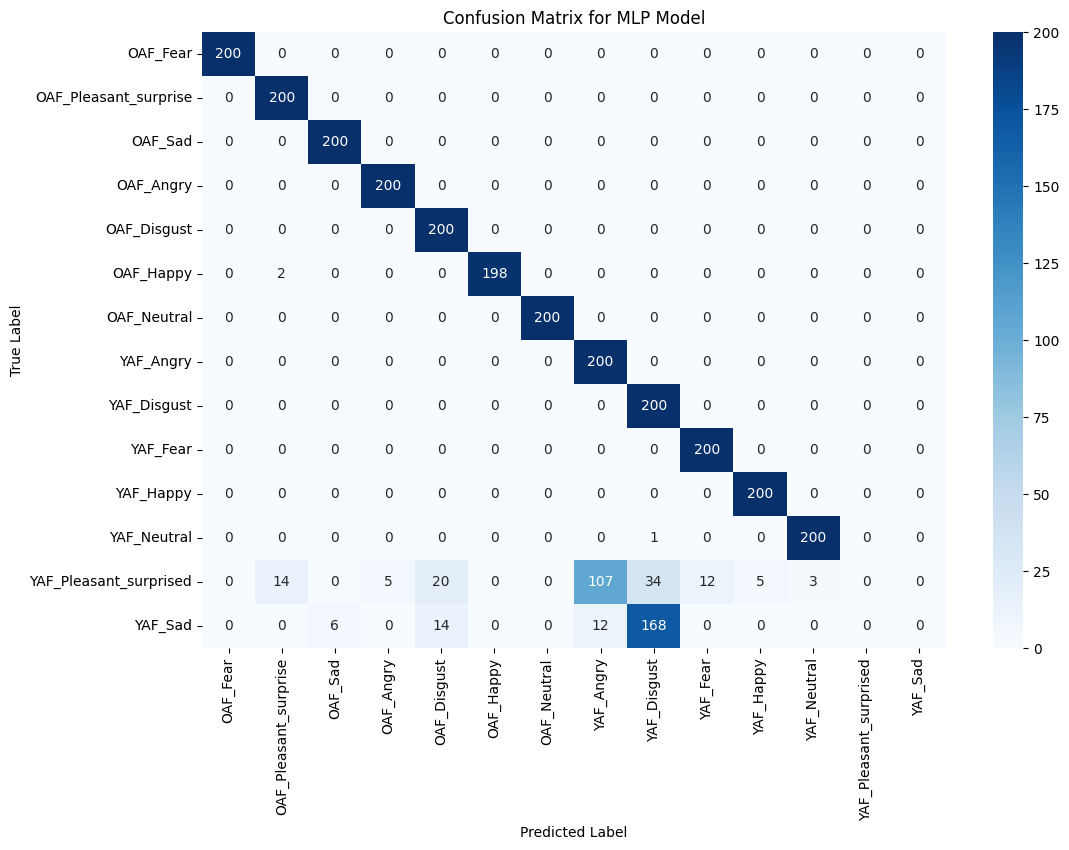

Model saved successfully!


In [46]:
# Confusion Matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=emotions.values(), yticklabels=emotions.values())
plt.title("Confusion Matrix for MLP Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("confusion_matrix_rf.png", dpi=300, bbox_inches="tight")
plt.show()
# Save the trained model
model.save("mlp.h5")
print("Model saved successfully!")


In [47]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model("mlp.h5")

# Function to predict emotion from a new file
def predict_emotion(file_path):
    feature = extract_features(file_path)
    feature = scaler.transform([feature])  # Normalize
    prediction = loaded_model.predict(feature)
    predicted_class = np.argmax(prediction)
    return emotions[predicted_class]

# Example usage
file_path = "D:\PYTHON\SPEECH\Tess\OAF_Sad\OAF_cheek_sad.wav"  # Change this to your test file
predicted_emotion = predict_emotion(file_path)
print(f"Predicted Emotion: {predicted_emotion}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Predicted Emotion: OAF_Sad


# SVM

In [48]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import make_pipeline

C:\Users\HP\AppData\Local\Temp\ipykernel_17416\2216069962.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(emotion_counts.keys()), y=list(emotion_counts.values()), palette="viridis")


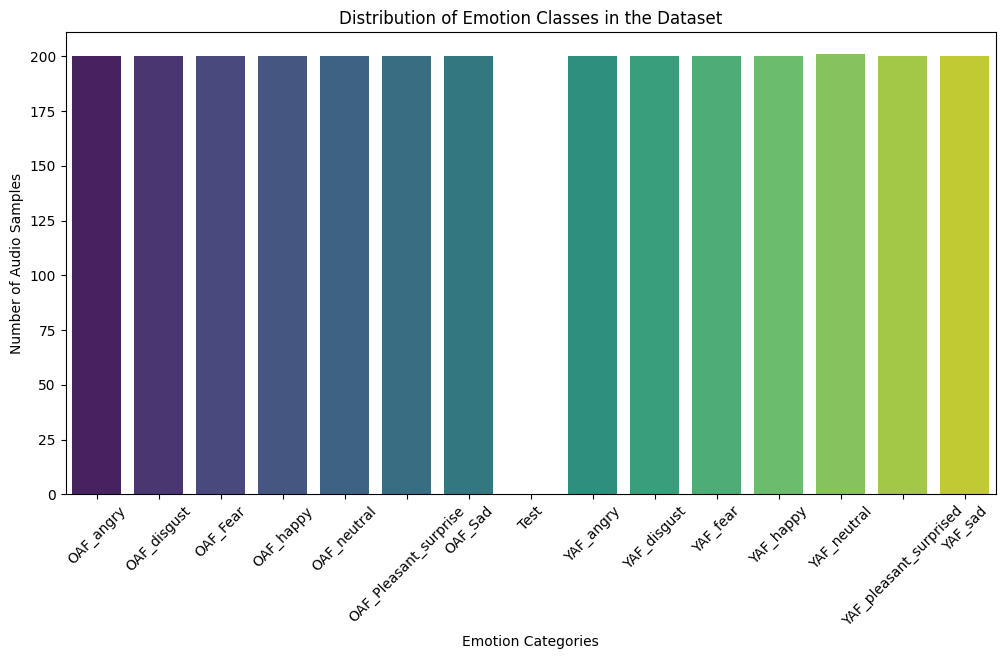

In [49]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Define the dataset path
dataset_path = "D:/PYTHON/SPEECH/Tess"
test_dataset_path = "D:/PYTHON/SPEECH/Tess/test"

# Custom emotion classes
emotions = {
    0: 'OAF_Fear', 1: 'OAF_Pleasant_surprise', 2: 'OAF_Sad', 3: 'OAF_angry',
    4: 'OAF_disgust', 5: 'OAF_happy', 6: 'OAF_neutral', 7: 'YAF_angry',
    8: 'YAF_disgust', 9: 'YAF_fear', 10: 'YAF_happy', 11: 'YAF_neutral',
    12: 'YAF_pleasant_surprised', 13: 'YAF_sad'
}

# Count the number of files per emotion
emotion_counts = Counter()
for emotion in os.listdir(dataset_path):
    emotion_folder = os.path.join(dataset_path, emotion)
    if os.path.isdir(emotion_folder):
        num_files = len([f for f in os.listdir(emotion_folder) if f.endswith(".wav")])
        emotion_counts[emotion] = num_files

# Plot distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(emotion_counts.keys()), y=list(emotion_counts.values()), palette="viridis")
plt.xticks(rotation=45)
plt.xlabel("Emotion Categories")
plt.ylabel("Number of Audio Samples")
plt.title("Distribution of Emotion Classes in the Dataset")
plt.show()


In [50]:
# Function to extract MFCC features
def extract_features(file_path, n_mfcc=40):
    y, sr = librosa.load(file_path, sr=22050)  # Load audio file
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)  # Compute MFCCs
    return np.mean(mfcc.T, axis=0)  # Take mean to get fixed-length feature vector

# Load dataset function
def load_dataset(data_path):
    features, labels = [], []
    
    for label_id, emotion in emotions.items():
        emotion_folder = os.path.join(data_path, emotion)
        if os.path.exists(emotion_folder):  # Check if the folder exists
            for file in os.listdir(emotion_folder):
                if file.endswith(".wav"):
                    file_path = os.path.join(emotion_folder, file)
                    mfcc_features = extract_features(file_path)
                    features.append(mfcc_features)
                    labels.append(label_id)

    return np.array(features), np.array(labels)

In [51]:
# Load training and test datasets
X_train, y_train = load_dataset(dataset_path)
X_test, y_test = load_dataset(test_dataset_path)

# Train an SVM model with a pipeline (scaling + classification)
svm_model = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)


In [52]:
# Overall Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nOverall Accuracy:", accuracy)

# Classification report (Precision, Recall, F1-score for each class)
report = classification_report(y_test, y_pred, target_names=[emotions[i] for i in emotions], output_dict=True)

# Print precision, recall, F1-score, and accuracy for each class
print("\nDetailed Class-wise Metrics:\n")
for emotion, metrics in report.items():
    if emotion in emotions.values():  # Ensuring only class-wise metrics are printed
        print(f"Emotion: {emotion}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall: {metrics['recall']:.4f}")
        print(f"  F1-score: {metrics['f1-score']:.4f}")
        print(f"  Support: {metrics['support']}\n")



Overall Accuracy: 0.9996429846483399

Detailed Class-wise Metrics:

Emotion: OAF_Fear
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Support: 200.0

Emotion: OAF_Pleasant_surprise
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Support: 200.0

Emotion: OAF_Sad
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Support: 200.0

Emotion: OAF_angry
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Support: 200.0

Emotion: OAF_disgust
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Support: 200.0

Emotion: OAF_happy
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Support: 200.0

Emotion: OAF_neutral
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Support: 200.0

Emotion: YAF_angry
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Support: 200.0

Emotion: YAF_disgust
  Precision: 0.9950
  Recall: 1.0000
  F1-score: 0.9975
  Support: 200.0

Emotion: YAF_fear
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Sup

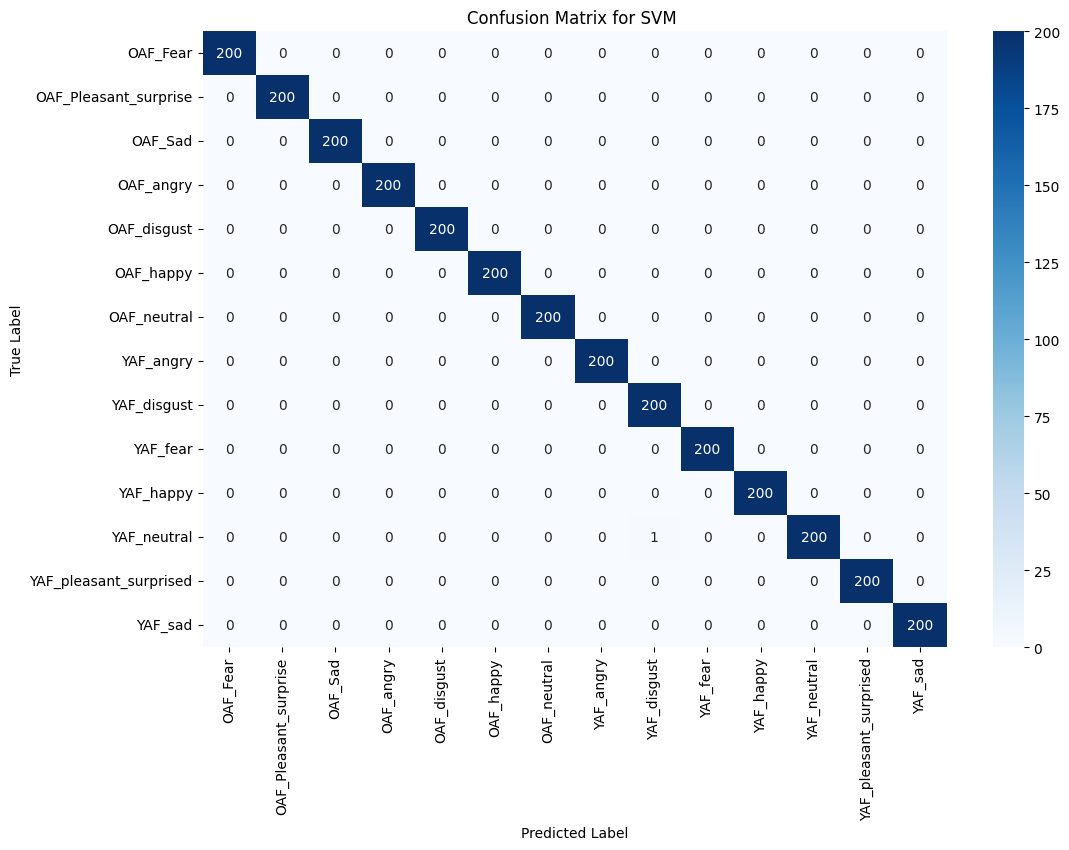

In [58]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=emotions.values(), yticklabels=emotions.values())
plt.title("Confusion Matrix for SVM ")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Save confusion matrix as a high-resolution image
plt.savefig("high_resolution_image.png", dpi=300, bbox_inches="tight")
plt.show()
model_filename = "svm.pkl"

In [59]:
def predict_emotion(file_path):
    """Predicts the emotion of a given audio file."""
    features = extract_features(file_path).reshape(1, -1)  # Reshape for model input
    prediction = model.predict(features)  # Prediction probabilities for each class
    predicted_class = np.argmax(prediction)  # Get the index of the highest probability
    return emotions[predicted_class]  # Return the corresponding emotion

# Example Usage
file_path = r"D:\PYTHON\SPEECH\Tess\OAF_Sad\OAF_bite_sad.wav"  # Replace with actual file path
predicted_emotion = predict_emotion(file_path)

print(f"Predicted Emotion: {predicted_emotion}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted Emotion: OAF_Sad
